In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
from churn_prediction.paths import SRC_DIR, PROCESSED_DIR, INTERIM_NOTEBOOK_DIR, RAW_DIR

In [11]:
products = pd.read_csv(RAW_DIR / "olist_products_dataset.csv")
order_items  = pd.read_csv(RAW_DIR / "olist_order_items_dataset.csv")

In [4]:

print(f"Products: {products.shape}")
print(f"Order_items: {order_items.shape}")

Products: (32951, 9)
Order_items: (99441, 8)


In [5]:
# 1. Tổng quan sản phẩm
print("\n=== TỔNG QUAN ===")
print(f"Số lượng sản phẩm: {products['product_id'].nunique()}")
print(f"Số lượng danh mục: {products['product_category_name'].nunique()}")
print(f"Tỉ lệ thiếu category: {products['product_category_name'].isna().mean()*100:.1f}%")


=== TỔNG QUAN ===
Số lượng sản phẩm: 32951
Số lượng danh mục: 73
Tỉ lệ thiếu category: 1.9%


In [12]:
# 2. Top/Bottom danh mục
# Merge để biết doanh thu theo danh mục
merged = order_items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')


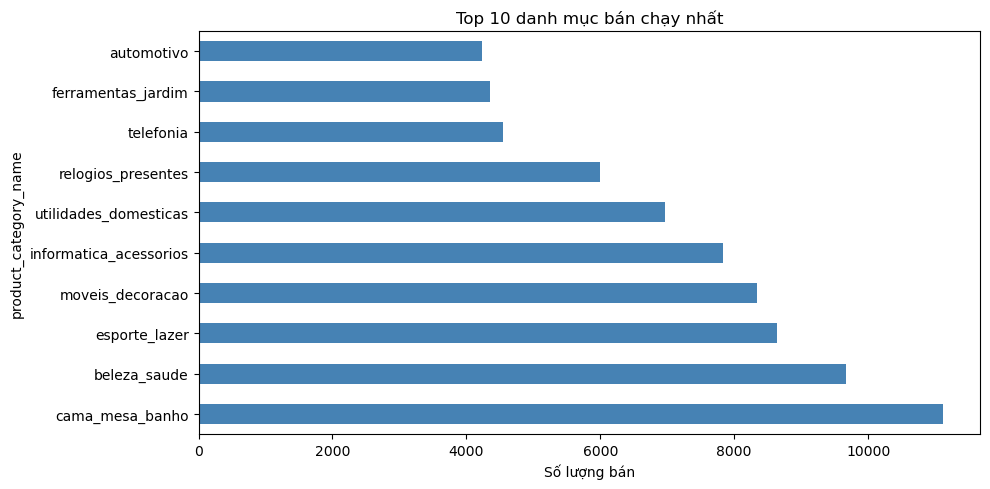

In [13]:
# Top 10 danh mục bán chạy
top_categories = merged.groupby('product_category_name')['order_id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_categories.plot(kind='barh', color='steelblue')
plt.title('Top 10 danh mục bán chạy nhất')
plt.xlabel('Số lượng bán')
plt.tight_layout()
plt.show()


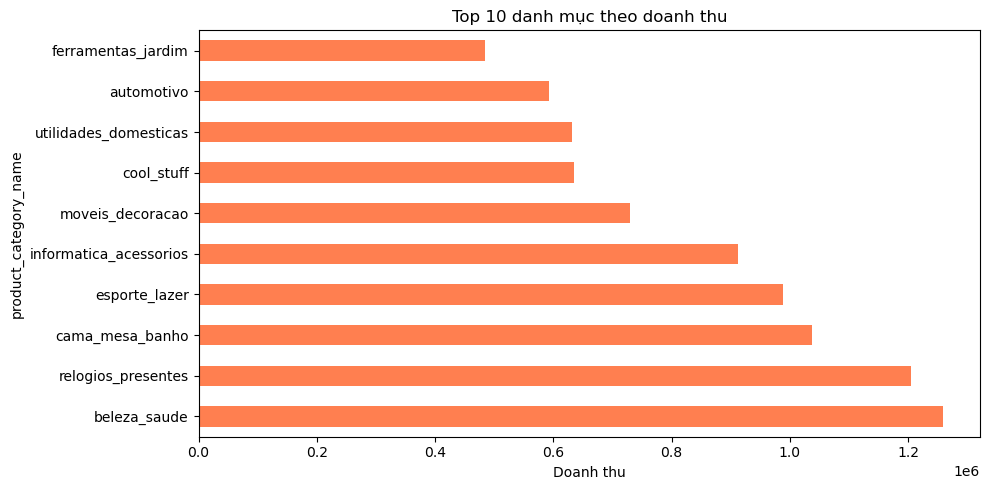

In [14]:
# 3. Top doanh thu theo danh mục
revenue_by_cat = merged.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
revenue_by_cat.plot(kind='barh', color='coral')
plt.title('Top 10 danh mục theo doanh thu')
plt.xlabel('Doanh thu')
plt.tight_layout()
plt.show()

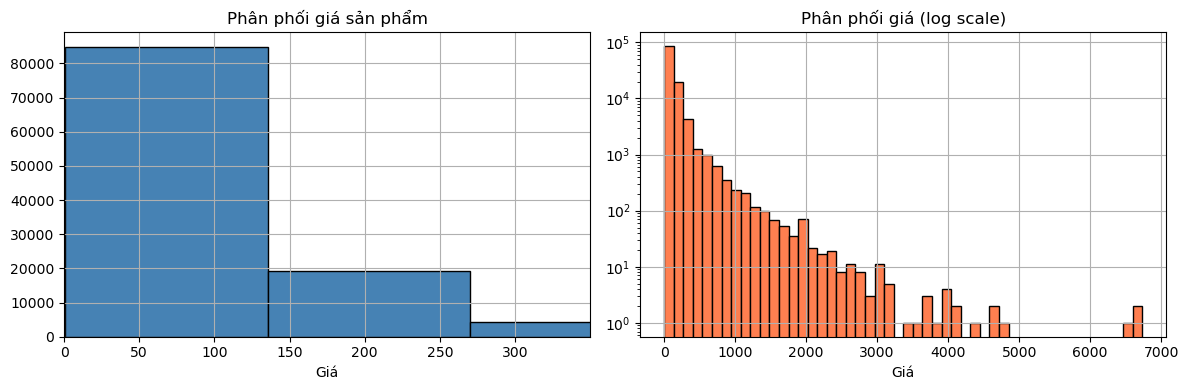


Thống kê giá:
count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64


In [15]:
# 4. Phân phối giá sản phẩm
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
order_items['price'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Phân phối giá sản phẩm')
plt.xlabel('Giá')
plt.xlim(0, order_items['price'].quantile(0.95))

plt.subplot(1, 2, 2)
order_items['price'].hist(bins=50, color='coral', edgecolor='black', log=True)
plt.title('Phân phối giá (log scale)')
plt.xlabel('Giá')
plt.tight_layout()
plt.show()
print(f"\nThống kê giá:")
print(order_items['price'].describe())

In [16]:
# 5. Sản phẩm bán chạy nhất
top_products = order_items.groupby('product_id')['order_id'].count().sort_values(ascending=False).head(10)
print(f"\n=== TOP 10 SẢN PHẨM BÁN CHẠY ===")
print(top_products)


=== TOP 10 SẢN PHẨM BÁN CHẠY ===
product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: order_id, dtype: int64


In [17]:
# 6. Sản phẩm có doanh thu cao nhất
top_revenue = order_items.groupby('product_id')['price'].sum().sort_values(ascending=False).head(10)
print(f"\n=== TOP 10 SẢN PHẨM DOANH THU CAO NHẤT ===")
print(top_revenue)


=== TOP 10 SẢN PHẨM DOANH THU CAO NHẤT ===
product_id
bb50f2e236e5eea0100680137654686c    63885.00
6cdd53843498f92890544667809f1595    54730.20
d6160fb7873f184099d9bc95e30376af    48899.34
d1c427060a0f73f6b889a5c7c61f2ac4    47214.51
99a4788cb24856965c36a24e339b6058    43025.56
3dd2a17168ec895c781a9191c1e95ad7    41082.60
25c38557cf793876c5abdd5931f922db    38907.32
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
53b36df67ebb7c41585e8d54d6772e08    37683.42
aca2eb7d00ea1a7b8ebd4e68314663af    37608.90
Name: price, dtype: float64


In [19]:
# 7. Kích thước sản phẩm (weight, length, height, width)
product_dims = products[['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']]

print(f"\n=== THỐNG KÊ KÍCH THƯỚC SẢN PHẨM ===")
print(product_dims.describe())



=== THỐNG KÊ KÍCH THƯỚC SẢN PHẨM ===
       product_weight_g  product_length_cm  product_height_cm  \
count      32949.000000       32949.000000       32949.000000   
mean        2276.472488          30.815078          16.937661   
std         4282.038731          16.914458          13.637554   
min            0.000000           7.000000           2.000000   
25%          300.000000          18.000000           8.000000   
50%          700.000000          25.000000          13.000000   
75%         1900.000000          38.000000          21.000000   
max        40425.000000         105.000000         105.000000   

       product_width_cm  
count      32949.000000  
mean          23.196728  
std           12.079047  
min            6.000000  
25%           15.000000  
50%           20.000000  
75%           30.000000  
max          118.000000  


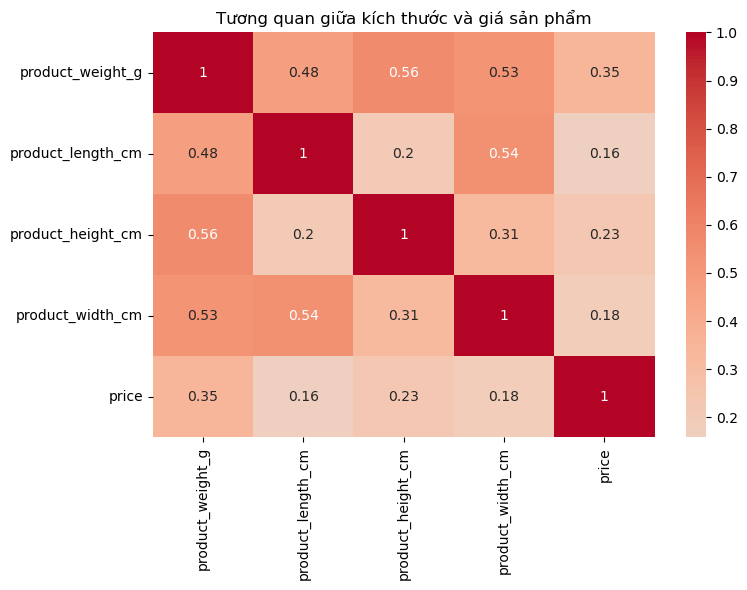

In [20]:
# 8. Tương quan giữa kích thước và giá
# Merge để có giá
prod_with_price = products.merge(order_items[['product_id', 'price']].drop_duplicates('product_id'), on='product_id', how='left')

corr_dims = prod_with_price[['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'price']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_dims, annot=True, cmap='coolwarm', center=0)
plt.title('Tương quan giữa kích thước và giá sản phẩm')
plt.tight_layout()
plt.show()

In [21]:
# 9. Phân tích category thiếu
missing_cat = products[products['product_category_name'].isna()]
print(f"\n=== SẢN PHẨM KHÔNG CÓ DANH MỤC ===")
print(f"Số lượng: {len(missing_cat)} sản phẩm")
print(f"Tỉ lệ: {len(missing_cat)/len(products)*100:.2f}%")


=== SẢN PHẨM KHÔNG CÓ DANH MỤC ===
Số lượng: 610 sản phẩm
Tỉ lệ: 1.85%


In [22]:
# 10. Kết luận
print("\n=== KẾT LUẬN ===")
print(f"✓ Số lượng sản phẩm: {len(products):,}")
print(f"✓ Giá trung bình: ${order_items['price'].mean():.2f}")
print(f"✓ Giá trung vị: ${order_items['price'].median():.2f}")
print(f"✓ Danh mục bán chạy nhất: {top_categories.index[0]}")
print(f"✓ Danh mục doanh thu cao nhất: {revenue_by_cat.index[0]}")
print(f"✓ Tương quan giữa weight và price: {corr_dims.loc['product_weight_g', 'price']:.2f}")


=== KẾT LUẬN ===
✓ Số lượng sản phẩm: 32,951
✓ Giá trung bình: $120.65
✓ Giá trung vị: $74.99
✓ Danh mục bán chạy nhất: cama_mesa_banho
✓ Danh mục doanh thu cao nhất: beleza_saude
✓ Tương quan giữa weight và price: 0.35
